In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## classification of ML using Logistic regression and Naive Bias 

In [2]:
cd

C:\Users\USER


In [3]:
text=pd.read_json("Downloads/Training_data.json",lines=True)

In [4]:
text.head(3)

,text,parent_comment,article_title,article_url,platform,platform_id,composite_toxic
0,"WTF, y'all never made MRE fart balloons in the...",None,Triangular UFO hovers over California military...,https://www.dailymail.co.uk/news/article-12112...,reddit,jlcm021,"[[False, 74], [True, 323], [False, 1028], [Fal..."
1,No apologies !! McCall has balls ! Ccp is not...,None,China sentences elderly US citizen to life in ...,https://www.cnn.com/2023/05/15/china/china-jai...,youtube,Ugws8gNW7eJyE9VHeM14AaABAg,"[[False, 216], [False, 197], [False, 1039], [F..."
2,What ever you need to tell yourself to sleep a...,I wonder how many undercover agents will be go...,Jan. 6 defendant who put foot on desk in Pelos...,https://www.cbsnews.com/news/richard-barnett-j...,youtube,UgxHlqwNcVssLHUr4yF4AaABAg.9q7kOunSlu-9q7lHH4he6S,"[[True, 192], [True, 193], [True, 260], [True,..."


In [5]:
text.shape

(4000, 7)

In [6]:
text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   text             4000 non-null   object
 1   parent_comment   1402 non-null   object
 2   article_title    4000 non-null   object
 3   article_url      4000 non-null   object
 4   platform         4000 non-null   object
 5   platform_id      4000 non-null   object
 6   composite_toxic  4000 non-null   object
dtypes: object(7)
memory usage: 218.9+ KB


In [7]:
text.isna().sum()

text                  0
parent_comment     2598
article_title         0
article_url           0
platform              0
platform_id           0
composite_toxic       0
dtype: int64

In [8]:
text.isnull().sum()

text                  0
parent_comment     2598
article_title         0
article_url           0
platform              0
platform_id           0
composite_toxic       0
dtype: int64

In [9]:
trained_text=text[["text","composite_toxic"]]
trained_text.head(5)

,text,composite_toxic
0,"WTF, y'all never made MRE fart balloons in the...","[[False, 74], [True, 323], [False, 1028], [Fal..."
1,No apologies !! McCall has balls ! Ccp is not...,"[[False, 216], [False, 197], [False, 1039], [F..."
2,What ever you need to tell yourself to sleep a...,"[[True, 192], [True, 193], [True, 260], [True,..."
3,@exZACKly @CBSNews Fuck off Nazi,"[[True, 92], [False, 218], [True, 69], [True, ..."
4,Texas is a republican sponsored killing ground...,"[[False, 56], [True, 207], [False, 218], [Fals..."


In [10]:
trained_text=trained_text.rename(columns={"composite_toxic":"label"})
trained_text.head(3)

,text,label
0,"WTF, y'all never made MRE fart balloons in the...","[[False, 74], [True, 323], [False, 1028], [Fal..."
1,No apologies !! McCall has balls ! Ccp is not...,"[[False, 216], [False, 197], [False, 1039], [F..."
2,What ever you need to tell yourself to sleep a...,"[[True, 192], [True, 193], [True, 260], [True,..."


### Flatting the label columns 

In [11]:
def flatten_annotations(row):
    annotations=[label for label,worker_id in row] #extracting only true and false from each row
    return sum(annotations)>(len(annotations)/2) # return the one that is greather than halve of the number of times it appears
    

In [12]:
trained_text["label"]=trained_text["label"].apply(flatten_annotations)

In [13]:
trained_text.head()

,text,label
0,"WTF, y'all never made MRE fart balloons in the...",False
1,No apologies !! McCall has balls ! Ccp is not...,False
2,What ever you need to tell yourself to sleep a...,True
3,@exZACKly @CBSNews Fuck off Nazi,True
4,Texas is a republican sponsored killing ground...,False


<Axes: xlabel='label'>

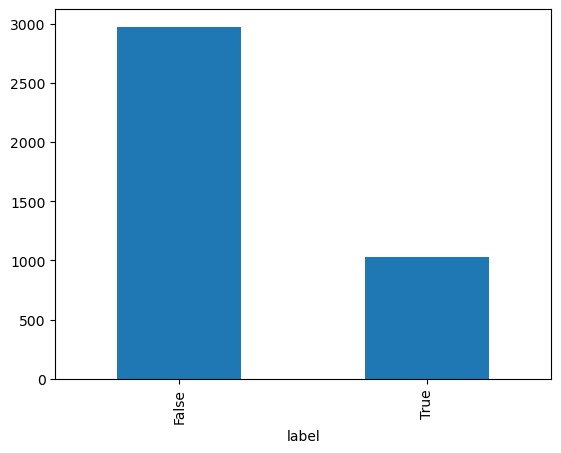

In [14]:
trained_text['label'].value_counts().plot(kind='bar')

In [15]:
trained_text['label'].value_counts()

label
False    2974
True     1026
Name: count, dtype: int64

In [16]:
trained_text[trained_text['label']==True]

,text,label
2,What ever you need to tell yourself to sleep a...,True
3,@exZACKly @CBSNews Fuck off Nazi,True
7,@noon4s @AndrewJakeMIII @AP @elonmusk MAGA mor...,True
8,yeah i doubt that's false. Biden wants Drag qu...,True
10,Cruise missiles aren't that hard to shoot down...,True
...,...,...
3980,Thanks to all the idiots that voted for Graham...,True
3981,@petestrzok He is a sick f**ck! Like a sadist...,True
3985,"DeFascist is waging war on, non-white, non-het...",True
3992,Who the fuck is the EU to tell an American com...,True


### Stemming your text column

In [17]:
import nltk
#nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
port_stemmer=PorterStemmer()

In [18]:
import re #remove character that are not alphabetics
from nltk.corpus import stopwords #words in in english dictionary

def stemming(content):
    stemmed_content=re.sub('[^a-zA-Z]',' ',content)
    stemmed_content=stemmed_content.lower()
    stemmed_content=stemmed_content.split()
    stemmed_content=[port_stemmer.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content=" ".join(stemmed_content) 
    return stemmed_content

In [19]:
trained_text["text_stemmed_and_proccessed"]=trained_text['text'].apply(stemming)

In [20]:
trained_text.head(5)

,text,label,text_stemmed_and_proccessed
0,"WTF, y'all never made MRE fart balloons in the...",False,wtf never made mre fart balloon stump fuck kid...
1,No apologies !! McCall has balls ! Ccp is not...,False,apolog mccall ball ccp noth full crap
2,What ever you need to tell yourself to sleep a...,True,ever need tell sleep night fuck retard
3,@exZACKly @CBSNews Fuck off Nazi,True,exzackli cbsnew fuck nazi
4,Texas is a republican sponsored killing ground...,False,texa republican sponsor kill ground teach thes...


### Lementizating of the test column to confirm
Ai cloaud version

In [21]:
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag,word_tokenize
from nltk.corpus import wordnet
lemmatizer=WordNetLemmatizer()
#nltk.download('averaged_perceptron_tagger_eng')
#nltk.download('wordnet')
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
def lemmatize_if_in_dictionary(word, pos):
    if wordnet.synsets(word):   # non-empty list means the word exists in WordNet
        return lemmatizer.lemmatize(word, pos)
    else:
        return word             # not a recognized English word — leave unchanged
def lementazation(content):
    stemmed_content=re.sub('[^a-zA-Z]',' ',content)
    stemmed_content=stemmed_content.lower()
    stemmed_content=stemmed_content.split()
    stemmed_content=[word for word in stemmed_content if not word in stopwords.words('english')]
    tagged_words=pos_tag(stemmed_content)
    lemetized_words=[lemmatize_if_in_dictionary(word,get_wordnet_pos(tag)) for word,tag in tagged_words]
    return " ".join(lemetized_words) 
    

In [22]:
trained_text["text_lemmatizedAI_and_proccessed"]=trained_text['text'].apply(lementazation)

In [23]:
trained_text.head()

,text,label,text_stemmed_and_proccessed,text_lemmatizedAI_and_proccessed
0,"WTF, y'all never made MRE fart balloons in the...",False,wtf never made mre fart balloon stump fuck kid...,wtf never make mre fart balloon stump fuck kid...
1,No apologies !! McCall has balls ! Ccp is not...,False,apolog mccall ball ccp noth full crap,apology mccall ball ccp nothing full crap
2,What ever you need to tell yourself to sleep a...,True,ever need tell sleep night fuck retard,ever need tell sleep night fuck retard
3,@exZACKly @CBSNews Fuck off Nazi,True,exzackli cbsnew fuck nazi,exzackly cbsnews fuck nazi
4,Texas is a republican sponsored killing ground...,False,texa republican sponsor kill ground teach thes...,texas republican sponsor kill ground teach the...


In [24]:
#CLASS PRACTICE
lemmatizer=WordNetLemmatizer()
def lemmatizerCLASS(content):
    stemmed_content=re.sub('[^a-zA-Z]',' ',content)
    stemmed_content=stemmed_content.lower()
    stemmed_content=stemmed_content.split()
    stemmed_content=[lemmatizer.lemmatize(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content=" ".join(stemmed_content) 
    return stemmed_content


    

In [25]:
trained_text["text_lemmatizedCLASS_and_proccessed"]=trained_text['text'].apply(lemmatizerCLASS)

In [26]:
trained_text.head(10)

,text,label,text_stemmed_and_proccessed,text_lemmatizedAI_and_proccessed,text_lemmatizedCLASS_and_proccessed
0,"WTF, y'all never made MRE fart balloons in the...",False,wtf never made mre fart balloon stump fuck kid...,wtf never make mre fart balloon stump fuck kid...,wtf never made mre fart balloon stump fucking ...
1,No apologies !! McCall has balls ! Ccp is not...,False,apolog mccall ball ccp noth full crap,apology mccall ball ccp nothing full crap,apology mccall ball ccp nothing full crap
2,What ever you need to tell yourself to sleep a...,True,ever need tell sleep night fuck retard,ever need tell sleep night fuck retard,ever need tell sleep night fucking retard
3,@exZACKly @CBSNews Fuck off Nazi,True,exzackli cbsnew fuck nazi,exzackly cbsnews fuck nazi,exzackly cbsnews fuck nazi
4,Texas is a republican sponsored killing ground...,False,texa republican sponsor kill ground teach thes...,texas republican sponsor kill ground teach the...,texas republican sponsored killing ground teac...
5,"I get that calling the rapporteur a ""fake job""...",False,get call rapporteur fake job score point base ...,get call rapporteur fake job score point base ...,get calling rapporteur fake job score point ba...
6,"Ok, so when are people getting arrested for l...",False,ok peopl get arrest lie made bullshit hillari ...,ok people get arrest lie make bullshit hillary...,ok people getting arrested lying made bullshit...
7,@noon4s @AndrewJakeMIII @AP @elonmusk MAGA mor...,True,noon andrewjakemiii ap elonmusk maga moron use...,noon andrewjakemiii ap elonmusk maga moron use...,noon andrewjakemiii ap elonmusk maga moron use...
8,yeah i doubt that's false. Biden wants Drag qu...,True,yeah doubt fals biden want drag queen school n...,yeah doubt false biden want drag queen school ...,yeah doubt false biden want drag queen school ...
9,">\t(unless signed contract exists, which is wh...",False,unless sign contract exist ev credit wait see ...,unless sign contract exist ev credit wait see ...,unless signed contract exists ev credit wait s...


In [27]:

tx_train=trained_text["text_lemmatizedCLASS_and_proccessed"]
y_train=trained_text['label']

In [28]:
y_train

0       False
1       False
2        True
3        True
4       False
        ...  
3995    False
3996    False
3997    False
3998    False
3999     True
Name: label, Length: 4000, dtype: bool

In [29]:
# importing sklearn component for featuring and extraction
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer # converting text to numbers 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score # to evaluate model performance

In [30]:
# initializing the TF-IDF
tdif=TfidfVectorizer()
#fitting the vector into the diffrent traind dataset

tx_train=tdif.fit_transform(tx_train)

In [31]:
tx_train[0:15].toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [32]:
# balamcing using the SMOTE Techniques importing imblearn
import imblearn
from imblearn.over_sampling import SMOTE
from numpy import where
from collections import Counter 
x_train=tx_train
y_train=y_train
counter=Counter(y_train)
print("## ............UNSAMPLED DATASET.......##\n\n")
print(counter)

from imblearn import under_sampling,over_sampling
from imblearn.over_sampling import SMOTE
oversample=SMOTE()
x_train,y_train=oversample.fit_resample(x_train,y_train.astype(str))
counter=Counter(y_train)
print("\n\n##-----THE SAMPLED DATASET----##\n\n")
print(counter)

## ............UNSAMPLED DATASET.......##


Counter({False: 2974, True: 1026})


##-----THE SAMPLED DATASET----##


Counter({'False': 2974, 'True': 2974})


Text(0.5, 1.0, 'Distribution of labels after applying SMOTE')

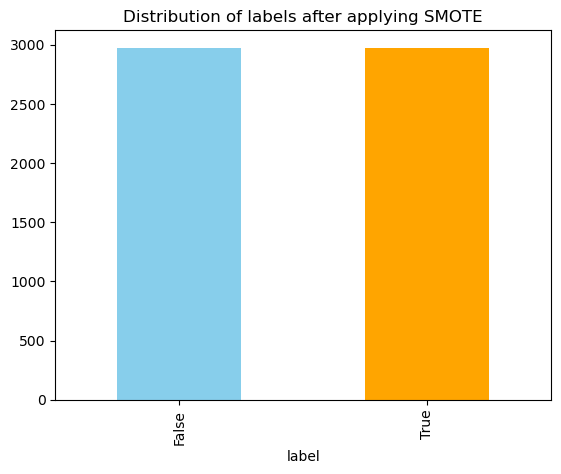

In [34]:
#sns.countplot(x=y_train,color=['skyblue', 'orange']);
y_train.value_counts().plot(kind='bar',color=['skyblue', 'orange']
);
plt.title("Distribution of labels after applying SMOTE")
#plt.savefig("with_SMOTE_classification.png",dpi=300,bbox_inches='tight')

In [35]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_train=le.fit_transform(y_train)


In [36]:
y_train

array([0, 0, 1, ..., 1, 1, 1])

### Model training and evaluation

In [37]:
print("inital Logistical Regression model...\n")
logmodel=LogisticRegression(max_iter=1000) # initalizing logistical regression
logmodel.fit(x_train,y_train) #fitting data to my model
print("Training data has been fit intot model,evaluating model..\n")
x_train_prediction=logmodel.predict(x_train)
training_data_accuracy=classification_report(y_train,x_train_prediction)
confusion_matrics=confusion_matrix(y_train,x_train_prediction)
print("classification report of LogisticRegression model on the training data: \n\n", (training_data_accuracy))
print("accuracy score of LogisticRegression model on the training data :",accuracy_score(y_train,x_train_prediction))
print("confusion matrix of LogisticRegression model on the training data :", (confusion_matrics))


inital Logistical Regression model...

Training data has been fit intot model,evaluating model..

classification report of LogisticRegression model on the training data: 

               precision    recall  f1-score   support

           0       0.87      0.90      0.89      2974
           1       0.90      0.87      0.88      2974

    accuracy                           0.89      5948
   macro avg       0.89      0.89      0.89      5948
weighted avg       0.89      0.89      0.89      5948

accuracy score of LogisticRegression model on the training data : 0.8853396099529254
confusion matrix of LogisticRegression model on the training data : [[2678  296]
 [ 386 2588]]


In [38]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=50)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_train)
print(classification_report(y_train,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2974
           1       1.00      1.00      1.00      2974

    accuracy                           1.00      5948
   macro avg       1.00      1.00      1.00      5948
weighted avg       1.00      1.00      1.00      5948



In [39]:
# naive bayes method
print("initializing Naive Bayes Classification Model...\n")
nbmodel=MultinomialNB()
nbmodel.fit(x_train,y_train)
print("Training data has been fit into the model,evaluating\n")
# accuracy score of naive bayes classification
nbmodel_prediction=nbmodel.predict(x_train)
nbmodel_training_accuracy=classification_report(y_train,nbmodel_prediction)
print("classification report of naive bayes classification \n\n",(nbmodel_training_accuracy))
print("accuracy score of Naive Bayes model on the training data :",accuracy_score(y_train,nbmodel_prediction))
print('\n')

initializing Naive Bayes Classification Model...

Training data has been fit into the model,evaluating

classification report of naive bayes classification 

               precision    recall  f1-score   support

           0       0.97      0.88      0.92      2974
           1       0.89      0.97      0.93      2974

    accuracy                           0.93      5948
   macro avg       0.93      0.93      0.92      5948
weighted avg       0.93      0.93      0.92      5948

accuracy score of Naive Bayes model on the training data : 0.9250168123739072




In [40]:
test_data=pd.read_json("Downloads/Test_data.json",lines=True)

In [41]:
test_data.head()

,text,parent_comment,article_title,article_url,platform,platform_id
0,Ukrainian Bullshit.,Russian Propaganda,Kremlin drone: Zelensky denies Ukraine attacke...,https://www.bbc.com/news/world-europe-65471904,youtube,UgxjV6HRpnD6FUmw8aV4AaABAg.9pH-CgX5yEH9pH7BMIfAz5
1,@LibDems No one likes you.\nYou denied democra...,None,"UK economy shrank 0.3% in March, ONS figures show",https://news.sky.com/story/uk-economy-shrank-0...,twitter,1657052099564150784
2,@EPurpera @BBCNews POS terrorist dictator Putr...,@BBCNews They should make peace talk.,Ukraine war: Kyiv hit by new massive Russian d...,https://www.bbc.com/news/world-65736730,twitter,1662672469205958656
3,@howardfineman @darkblue714 Bullshit. CNN set ...,None,Opinion | Why CNN's Trump town hall was always...,https://www.msnbc.com/opinion/msnbc-opinion/cn...,twitter,1656508255454019587
4,"The war will be won by who ""wins"" the race bet...",What is the pope gonna do? Pray and throw a co...,Zelenskyy to meet with Pope Francis at Vatican...,https://apnews.com/article/zelenskyy-italy-vis...,reddit,jk1pm1m


In [42]:
test_data.shape

(500, 6)

In [43]:
test_text=test_data[["text"]]

In [44]:
test_text

,text
0,Ukrainian Bullshit.
1,@LibDems No one likes you.\nYou denied democra...
2,@EPurpera @BBCNews POS terrorist dictator Putr...
3,@howardfineman @darkblue714 Bullshit. CNN set ...
4,"The war will be won by who ""wins"" the race bet..."
...,...
495,"Without accountability for killing, and displa..."
496,@ShlomoBen1 Don’t know anyone who does. Why?\n...
497,@CNN Why would CT CLAIM anything on his grand ...
498,"Who should we rely on, yours? or your friend W..."


In [45]:
lemmatizer=WordNetLemmatizer()
def test_lemmatizerCLASS(content):
    stemmed_content=re.sub('[^a-zA-Z]',' ',content)
    stemmed_content=stemmed_content.lower()
    stemmed_content=stemmed_content.split()
    stemmed_content=[lemmatizer.lemmatize(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content=" ".join(stemmed_content) 
    return stemmed_content


In [46]:
test_text=test_text['text'].apply(test_lemmatizerCLASS)

In [47]:
test_text

0                                     ukrainian bullshit
1      libdems one like denied democracy actively wor...
2      epurpera bbcnews po terrorist dictator putrid ...
3      howardfineman darkblue bullshit cnn set fail k...
4      war win race russian collapse even ukraine tak...
                             ...                        
495    without accountability killing displacing whol...
496         shlomoben know anyone oh right hyperbole lie
497    cnn would ct claim anything grand nephew commi...
498    rely friend winnie lmao okay comrade dont make...
499    mf sucking dick behind locked door shot anyone...
Name: text, Length: 500, dtype: object

In [48]:
#tdif=TfidfVectorizer()
#fitting the vector into the diffrent traind dataset

test_train=tdif.transform(test_text)

In [49]:
test_train[0:15].toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [50]:
logmodel_prediction=logmodel.predict(test_train)

In [51]:
 nbmodel_prediction=nbmodel.predict(test_train)

In [52]:
result=pd.DataFrame({'text': test_data["text"],'predicted_logistical':logmodel_prediction,'predicted_naive':nbmodel_prediction})


In [53]:
result.head(50)

,text,predicted_logistical,predicted_naive
0,Ukrainian Bullshit.,1,1
1,@LibDems No one likes you.\nYou denied democra...,1,1
2,@EPurpera @BBCNews POS terrorist dictator Putr...,1,1
3,@howardfineman @darkblue714 Bullshit. CNN set ...,1,0
4,"The war will be won by who ""wins"" the race bet...",0,0
5,I say fuck Lewis Powell jr even more,1,1
6,What is the stand of Fascist Modi in support o...,1,1
7,LOL....Many of us have been through this two o...,0,0
8,@Phil_Lewis_ Damn white supremacists!,0,1
9,Thoughts & Prayers!\n\nOn to the next one in a...,0,0


In [54]:
result["toxic_and_nontoxic_prediction_naivebayes"]=result['predicted_naive'].astype(bool)

In [55]:
result.head(20)

,text,predicted_logistical,predicted_naive,toxic_and_nontoxic_prediction_naivebayes
0,Ukrainian Bullshit.,1,1,True
1,@LibDems No one likes you.\nYou denied democra...,1,1,True
2,@EPurpera @BBCNews POS terrorist dictator Putr...,1,1,True
3,@howardfineman @darkblue714 Bullshit. CNN set ...,1,0,False
4,"The war will be won by who ""wins"" the race bet...",0,0,False
5,I say fuck Lewis Powell jr even more,1,1,True
6,What is the stand of Fascist Modi in support o...,1,1,True
7,LOL....Many of us have been through this two o...,0,0,False
8,@Phil_Lewis_ Damn white supremacists!,0,1,True
9,Thoughts & Prayers!\n\nOn to the next one in a...,0,0,False


In [56]:
#result.to_csv("Final_predition_toxic_and_nontoxic_comment_on_social_media.csv",index=False)

In [57]:
model = MultinomialNB(alpha=0.5)
model.fit(x_train, y_train)
    
x_train_prediction = model.predict(x_train)
print(f"\n{'='*60}")
print(f"Naive Bayes with alpha={0.5}")
print(f"{'='*60}")
    
print("\n--- TRAINING DATA ---")
print("Accuracy:", accuracy_score(y_train, x_train_prediction))
print(classification_report(y_train, x_train_prediction))
    
#train_acc = accuracy_score(y_train, x_train_prediction)

    
#train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(y_train, x_train_prediction, 
                                                                                # average='binary', pos_label=1)
   
    
    


Naive Bayes with alpha=0.5

--- TRAINING DATA ---
Accuracy: 0.9361129791526563
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      2974
           1       0.90      0.98      0.94      2974

    accuracy                           0.94      5948
   macro avg       0.94      0.94      0.94      5948
weighted avg       0.94      0.94      0.94      5948



In [58]:
 x_train_prediction = model.predict(test_train)

In [59]:
result["hyper_niave_alph0.01_predict"]=x_train_prediction

In [60]:
result.head(30)

,text,predicted_logistical,predicted_naive,toxic_and_nontoxic_prediction_naivebayes,hyper_niave_alph0.01_predict
0,Ukrainian Bullshit.,1,1,True,1
1,@LibDems No one likes you.\nYou denied democra...,1,1,True,1
2,@EPurpera @BBCNews POS terrorist dictator Putr...,1,1,True,1
3,@howardfineman @darkblue714 Bullshit. CNN set ...,1,0,False,0
4,"The war will be won by who ""wins"" the race bet...",0,0,False,0
5,I say fuck Lewis Powell jr even more,1,1,True,1
6,What is the stand of Fascist Modi in support o...,1,1,True,1
7,LOL....Many of us have been through this two o...,0,0,False,0
8,@Phil_Lewis_ Damn white supremacists!,0,1,True,1
9,Thoughts & Prayers!\n\nOn to the next one in a...,0,0,False,0


In [61]:
#result.to_csv("total_Final_predition_toxic_and_nontoxic_comment_on_social_media.csv",index=False)

In [67]:
result["predicted_logistical"]=logmodel_prediction.astype(bool)
result["hyper_niave_alph0.01_predict"]=x_train_prediction.astype(bool)

In [68]:
result.head(20)

,text,predicted_logistical,predicted_naive,toxic_and_nontoxic_prediction_naivebayes,hyper_niave_alph0.01_predict
0,Ukrainian Bullshit.,True,1,True,True
1,@LibDems No one likes you.\nYou denied democra...,True,1,True,True
2,@EPurpera @BBCNews POS terrorist dictator Putr...,True,1,True,True
3,@howardfineman @darkblue714 Bullshit. CNN set ...,True,0,False,False
4,"The war will be won by who ""wins"" the race bet...",False,0,False,False
5,I say fuck Lewis Powell jr even more,True,1,True,True
6,What is the stand of Fascist Modi in support o...,True,1,True,True
7,LOL....Many of us have been through this two o...,False,0,False,False
8,@Phil_Lewis_ Damn white supremacists!,False,1,True,True
9,Thoughts & Prayers!\n\nOn to the next one in a...,False,0,False,False


In [69]:
result.to_csv("final_total_Final_predition_toxic_and_nontoxic_comment_on_social_media.csv",index=False)